## Modeling
In this notebook I test out different models and how they work on the dataset.

In [1]:
# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..')) # This is to ensure the path gets found correctly

import script.data_preprocessing as dp
import script.data_visualization as dv
import script.data_modeling as dm

In [2]:
# load in the data
X_train, X_val, X_test, y_train, y_val, y_test = dp.load_split_data('dataset1')

In [3]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_std_10,...,Tank temperature (Mean)_rolling_min_10,Tank temperature (Mean)_rolling_max_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_std_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10
0,3.769735,3.891036,3.855507,3.851978,-5.461369,-8.634564,-6.094472,0.705783,3.769339,-1.474697,...,-8.551901,-8.910197,-6.131227,-1.341737,-6.132574,-6.102468,0.706074,-0.150213,0.746822,0.665663
1,3.769277,3.913425,3.872355,3.880656,-5.523070,-8.705175,-6.120487,0.671932,3.769110,-1.474697,...,-8.624067,-8.910197,-6.144313,-1.341737,-6.159397,-6.102468,0.689142,-0.150213,0.712944,0.665663
2,3.769735,3.918827,3.902206,3.917088,-5.476060,-8.621725,-6.113054,0.711426,3.769186,-1.521096,...,-8.624067,-8.897344,-6.146183,-1.423712,-6.159397,-6.102468,0.696668,-0.399507,0.712944,0.671305
3,3.766759,3.889493,3.872355,3.874455,-5.487812,-8.698756,-6.116771,0.694498,3.768481,-0.612194,...,-8.624067,-8.897344,-6.148052,-1.453986,-6.159397,-6.102468,0.696198,-0.776360,0.712944,0.671305
4,3.766302,3.894123,3.890171,3.886086,-5.478998,-8.711594,-6.113054,0.705783,3.767966,-0.407643,...,-8.630627,-8.897344,-6.148426,-1.478823,-6.159397,-6.102468,0.698173,-0.941713,0.712944,0.671305


In [4]:
y_train.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Plug_future, dtype: float64

### Baseline model

In [5]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.968     1.000     0.984      1531
         1.0      0.000     0.000     0.000        50

    accuracy                          0.968      1581
   macro avg      0.484     0.500     0.492      1581
weighted avg      0.938     0.968     0.953      1581



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### RandomForestClassifier

In [6]:
model = dm.train_and_evaluate_rf(X_train, X_val, y_train, y_val)

Validation F1 Score: 0.932


### Check feature importance / redundancy

In [7]:
feat_imp = dp.get_feature_importance(model, X_train)

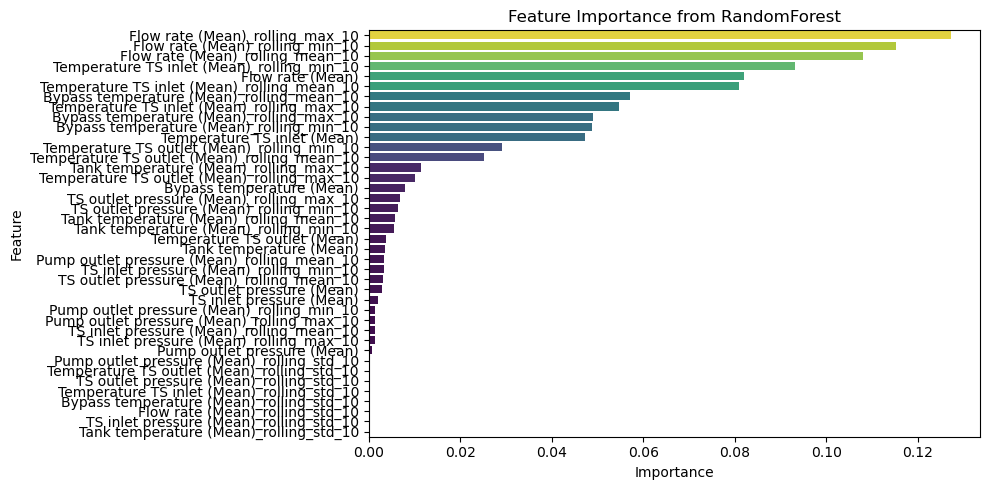

In [8]:
dv.plot_feature_importance(feat_imp)

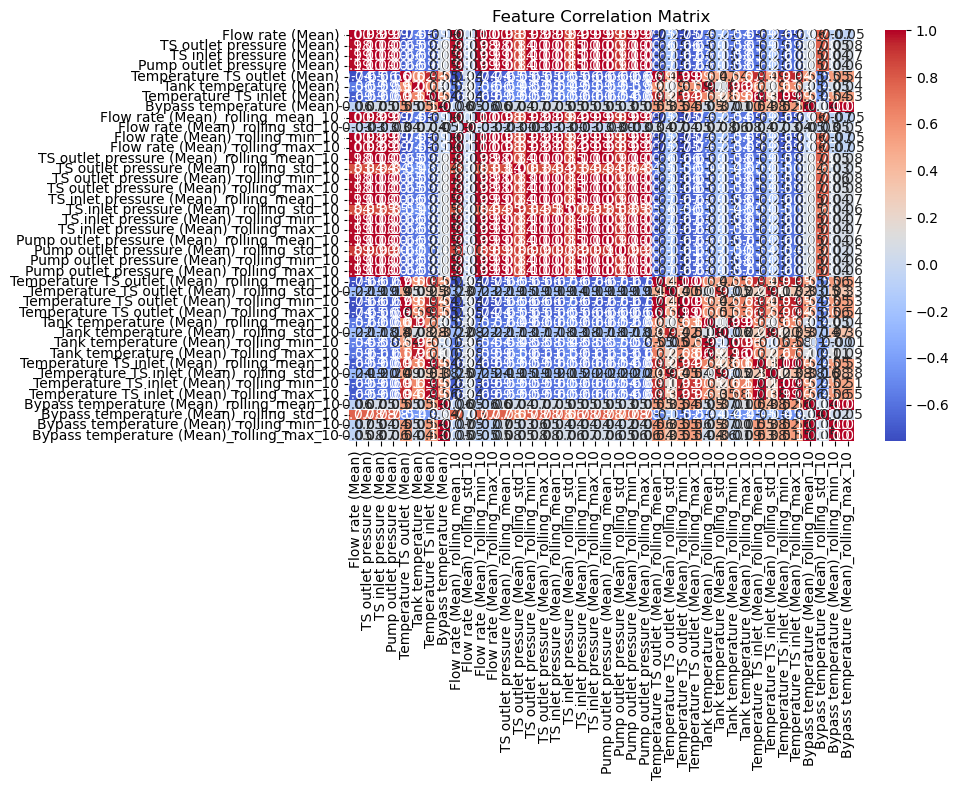

In [9]:
dv.plot_correlation_matrix(X_train)

In [10]:
feat_imp.describe()

count    4.000000e+01
mean     2.500000e-02
std      3.700371e-02
min      1.436860e-15
25%      1.367140e-03
50%      4.617745e-03
75%      4.765739e-02
max      1.272360e-01
dtype: float64

In [11]:
feat_imp.sort_values(ascending=False).head(20)

Flow rate (Mean)_rolling_max_10                 0.127236
Flow rate (Mean)_rolling_min_10                 0.115311
Flow rate (Mean)_rolling_mean_10                0.108040
Temperature TS inlet (Mean)_rolling_min_10      0.093225
Flow rate (Mean)                                0.082106
Temperature TS inlet (Mean)_rolling_mean_10     0.080830
Bypass temperature (Mean)_rolling_mean_10       0.057152
Temperature TS inlet (Mean)_rolling_max_10      0.054783
Bypass temperature (Mean)_rolling_max_10        0.048975
Bypass temperature (Mean)_rolling_min_10        0.048683
Temperature TS inlet (Mean)                     0.047315
Temperature TS outlet (Mean)_rolling_min_10     0.029051
Temperature TS outlet (Mean)_rolling_mean_10    0.025211
Tank temperature (Mean)_rolling_max_10          0.011390
Temperature TS outlet (Mean)_rolling_max_10     0.010063
Bypass temperature (Mean)                       0.007983
TS outlet pressure (Mean)_rolling_max_10        0.006747
TS outlet pressure (Mean)_rolli

In [12]:
feat_imp.min(), feat_imp.max()

(1.4368600783064338e-15, 0.12723595995130824)

In [13]:
X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_low_importance_features(X_train, X_val, X_test, feat_imp / feat_imp.sum())

⚙️ Removed 29 low-importance features (importance < 0.04)
    Remaining features: 11


In [14]:
X_train_reduced.head(5)

,Flow rate (Mean),Temperature TS inlet (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_min_10,Flow rate (Mean)_rolling_max_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10
0,3.769735,-6.094472,3.769339,3.772633,3.766054,-6.131227,-6.132574,-6.102468,0.706074,0.746822,0.665663
1,3.769277,-6.120487,3.769110,3.772175,3.766054,-6.144313,-6.159397,-6.102468,0.689142,0.712944,0.665663
2,3.769735,-6.113054,3.769186,3.772175,3.766054,-6.146183,-6.159397,-6.102468,0.696668,0.712944,0.671305
3,3.766759,-6.116771,3.768481,3.769658,3.766054,-6.148052,-6.159397,-6.102468,0.696198,0.712944,0.671305
4,3.766302,-6.113054,3.767966,3.769201,3.766054,-6.148426,-6.159397,-6.102468,0.698173,0.712944,0.671305


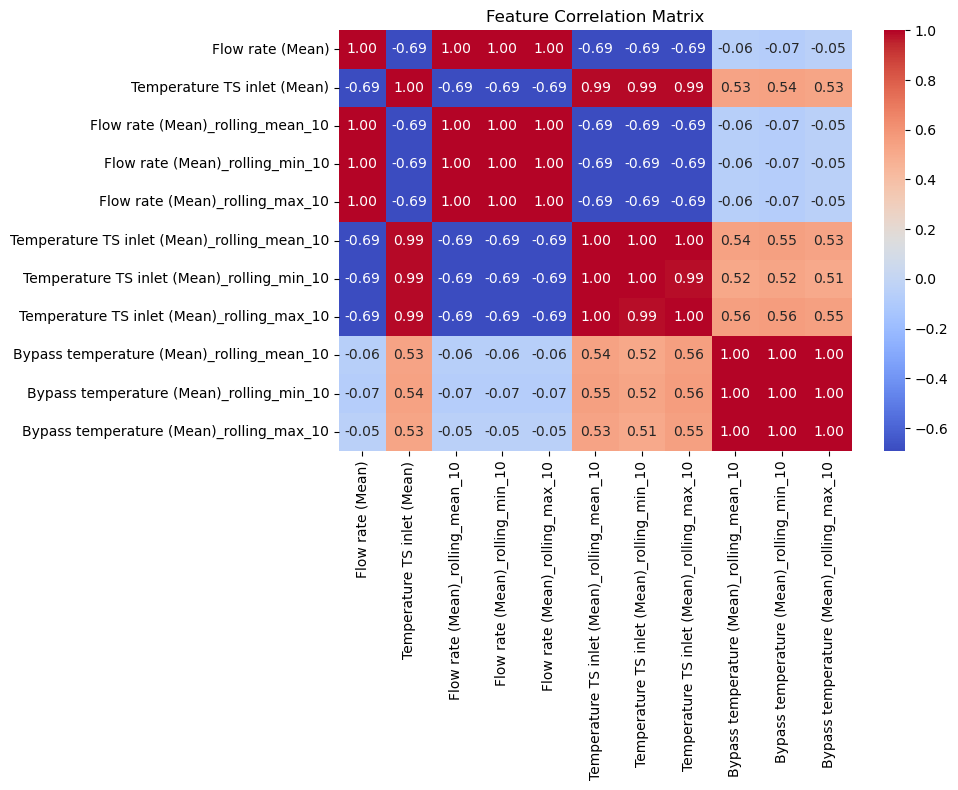

In [15]:
dv.plot_correlation_matrix(X_train_reduced)

In [16]:
y_train.shape

(329747,)

In [17]:
model_reduced = dm.train_and_evaluate_rf(X_train_reduced, X_val_reduced, y_train, y_val)

Validation F1 Score: 0.953


In [18]:
feat_imp_reduced = dp.get_feature_importance(model_reduced, X_train_reduced)

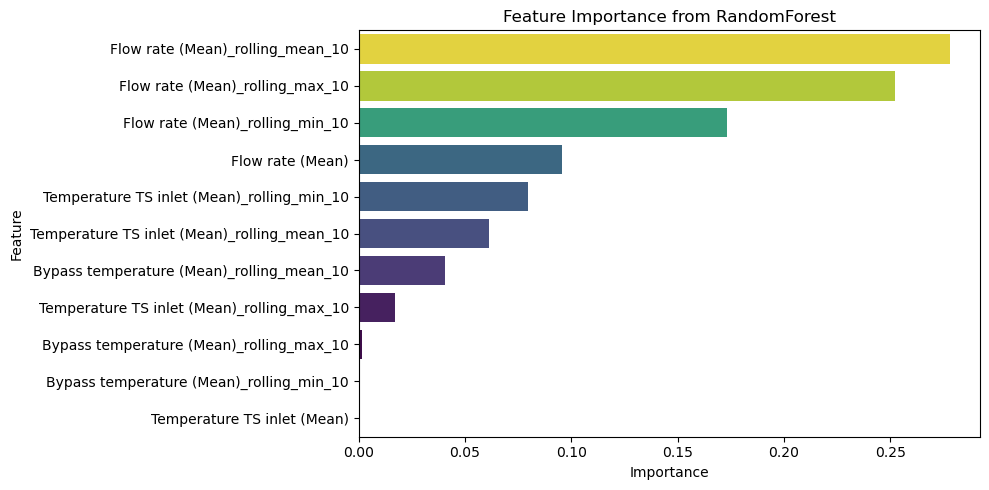

In [19]:
dv.plot_feature_importance(feat_imp_reduced)

### Upsampling

In [20]:
#dm.SMOTE_model(X_train_reduced, y_train, X_val_reduced, y_val)

### Downsampling

In [21]:
#dm.undersample_model(X_train_reduced, y_train, X_val_reduced, y_val)

In [22]:
# Check class balance for the target variable
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 329469 samples
  Class 1.0: 278 samples


# Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [28]:
y_train.value_counts(normalize=True)

Plug_future
0.0    0.999157
1.0    0.000843
Name: proportion, dtype: float64

In [23]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val, verbose_level=2, visualize=False)


🔍 Tuning Random Forest...
Searching over 4 hyperparameter combinations...
Params: {'n_estimators': 100, 'max_depth': 10} | Validation F1 Score = 0.1465
Params: {'n_estimators': 100, 'max_depth': 20} | Validation F1 Score = 0.3830
Params: {'n_estimators': 200, 'max_depth': 10} | Validation F1 Score = 0.0000
Params: {'n_estimators': 200, 'max_depth': 20} | Validation F1 Score = 0.0392

✅ Best parameters found: {'n_estimators': 100, 'max_depth': 20}
Best validation F1 Score: 0.3830
Best Random Forest model with params: {'n_estimators': 100, 'max_depth': 20} achieved validation F1 Score: 0.3830

🔍 Tuning Logistic Regression...
Searching over 4 hyperparameter combinations...
Params: {'C': 1.0, 'solver': 'lbfgs'} | Validation F1 Score = 0.2730
Params: {'C': 1.0, 'solver': 'liblinear'} | Validation F1 Score = 0.1462
Params: {'C': 0.5, 'solver': 'lbfgs'} | Validation F1 Score = 0.2627
Params: {'C': 0.5, 'solver': 'liblinear'} | Validation F1 Score = 0.1504

✅ Best parameters found: {'C': 1.0,

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/xgboost/sklearn.py", line 1682, in fit
    self._Booster = train(


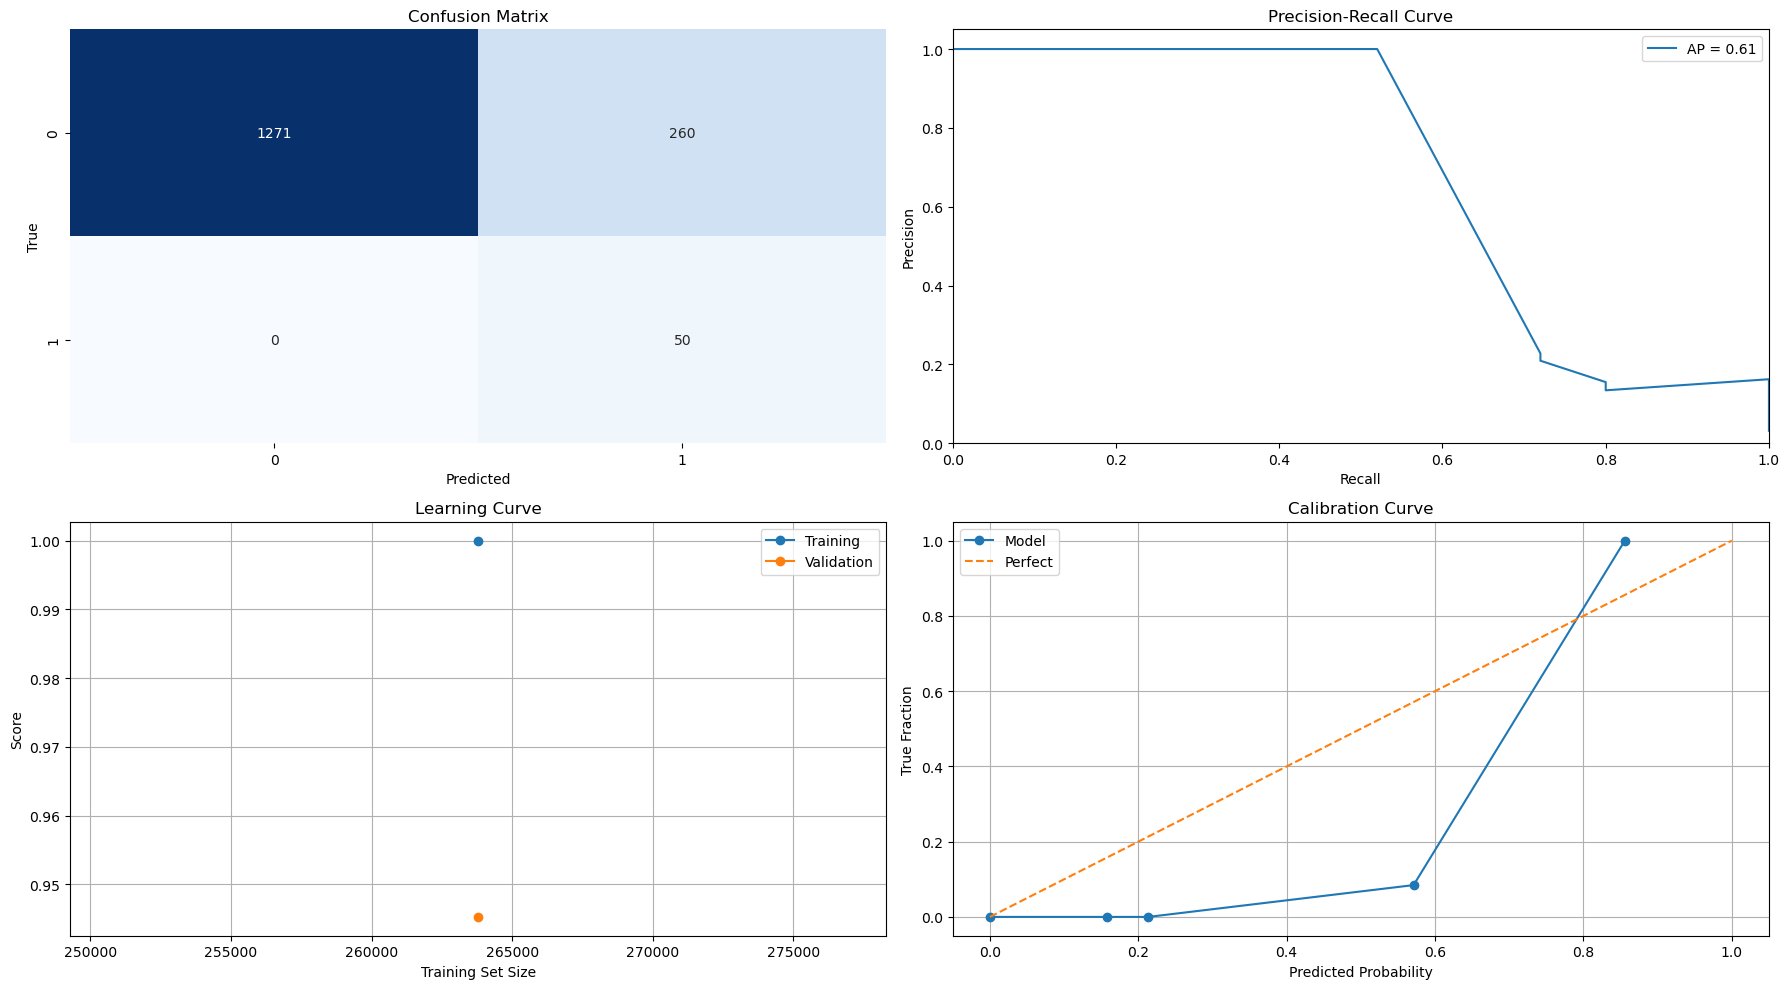

In [24]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_val)

dv.plot_all(best_model, X_val, y_val, train_sizes, train_scores, val_scores)

## Test best model on test dataset
Test the best model on the test dataset to check it´s generalization capabilities.

In [25]:
print(f"Evaluating best model ({best_model.__class__.__name__}) on test set:")
dm.retrain_final_model(X_train, X_val, y_train, y_val, best_model)
y_pred = dm.evaluate_model_on_test(best_model, X_test, y_test)

Evaluating best model (XGBClassifier) on test set:
[0 0 0 ... 0 0 0]
Test set results:
              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000      1582

    accuracy                          1.000      1582
   macro avg      1.000     1.000     1.000      1582
weighted avg      1.000     1.000     1.000      1582

F1 Score: 1.0


## Save best model


In [26]:
dm.save_model(best_model, "../models/best_pipeline.joblib")

Saved model to ../models/best_pipeline.joblib


### Visualize performance

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/xgboost/sklearn.py", line 1682, in fit
    self._Booster = train(


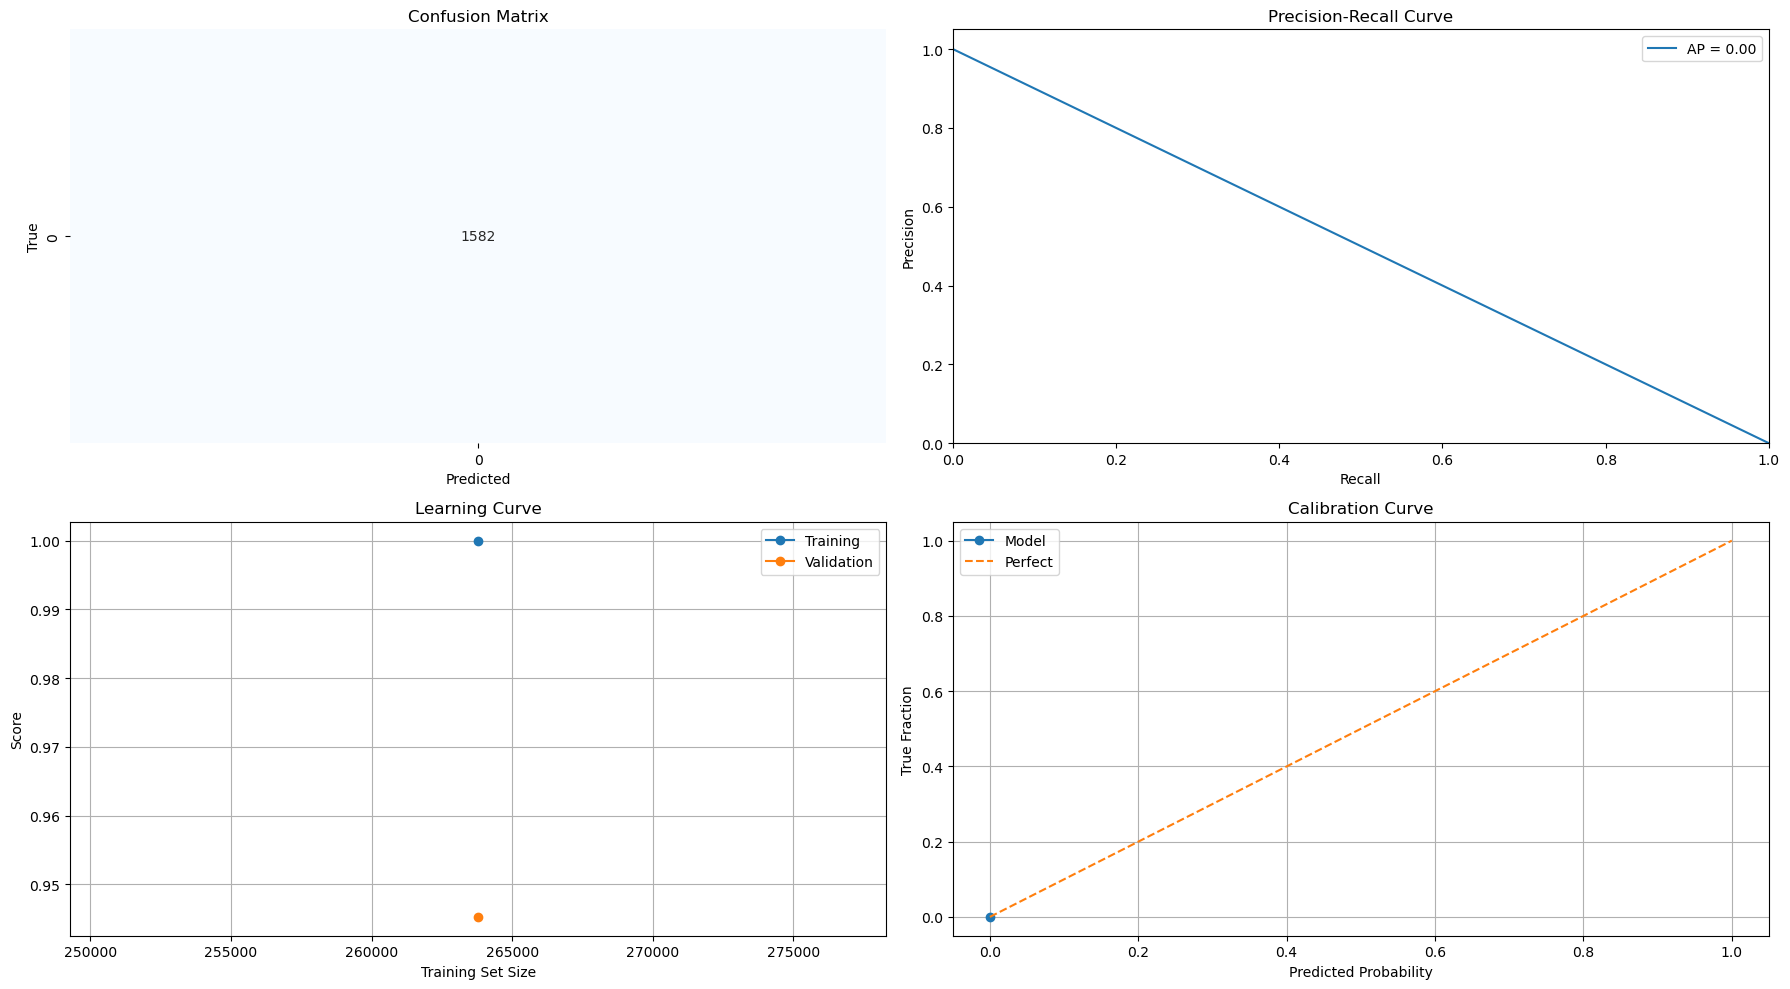

In [27]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_test)

dv.plot_all(best_model, X_test, y_test, train_sizes, train_scores, val_scores)